Airline Data Analysis in Wartime

In this project, I analyzed airline data from the Israeli airline El Al during wartime to understand the impact of emergency situations on operations, 
flight performance, demand, revenue, and profitability.
    
The objective is to perform statistical analysis, identify trends over time,and examine relationships between
operational metrics (delays and cancellations) and financial metrics (revenue and profitability), including period comparisons and anomaly detection.

The dataset is provided in a CSV file and includes operational and financial data.

For this analysis, I used Python with the libraries Pandas, NumPy, Matplotlib, and Seaborn to present insights and conclusions.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
pwd

'C:\\Users\\owner\\Desktop\\גון ברייס\\Python\\פרוייקט 3'

In [3]:
df = pd.read_csv("israeli_airline_full_data_.csv")

In [4]:
df.head()

,flight_id,origin,destination,seats_total,seats_sold,avg_price,revenue,passenger_id,gender,age,...,booking_id.1,reason,refund,passenger_id.2,points,flights_count,booking_date,Departure_Time,cancellation_date,season
0,0.0,TLV,ROM,193.0,193.0,342.0,66006.0,0.0,M,44.0,...,20958.0,Weather,314.0,0.0,89894.0,7.0,09/12/2025,14:20:00,NaN,Winter
1,1.0,TLV,ROM,300.0,233.0,369.0,85977.0,1.0,F,36.0,...,2302.0,Security,558.0,1.0,88045.0,5.0,14/07/2025,21:34:00,NaN,Summer
2,2.0,TLV,PAR,283.0,175.0,501.0,87675.0,2.0,F,48.0,...,22078.0,Weather,297.0,2.0,2346.0,28.0,22/04/2025,18:50:00,NaN,Spring
3,3.0,TLV,NYC,284.0,120.0,1172.0,140640.0,3.0,F,47.0,...,20562.0,Weather,858.0,3.0,6418.0,36.0,10/06/2024,18:15:00,NaN,Summer
4,4.0,TLV,NYC,169.0,126.0,1244.0,156744.0,4.0,F,23.0,...,26729.0,Security,321.0,4.0,67876.0,5.0,10/06/2024,17:24:00,NaN,Summer


In [5]:
file_path = "israeli_airline_full_data_.csv"
df = pd.read_csv(file_path)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format',lambda x: '{:,.2f}'.format(x).rstrip('0').rstrip('.'))


In [6]:
df.head()

,flight_id,origin,destination,seats_total,seats_sold,avg_price,revenue,passenger_id,gender,age,country,frequent_flyer,tier,booking_id,passenger_id.1,flight_id.1,price,class,status,cancel_id,booking_id.1,reason,refund,passenger_id.2,points,flights_count,booking_date,Departure_Time,cancellation_date,season
0,0,TLV,ROM,193,193,342,"66,006",0,M,44,USA,0,NaN,0,88,"3,948",879,Business,Completed,0,"20,958",Weather,314,0,"89,894",7,09/12/2025,14:20:00,NaN,Winter
1,1,TLV,ROM,300,233,369,"85,977",1,F,36,France,1,Silver,1,"5,619","3,240","1,244",Business,Completed,1,"2,302",Security,558,1,"88,045",5,14/07/2025,21:34:00,NaN,Summer
2,2,TLV,PAR,283,175,501,"87,675",2,F,48,USA,0,NaN,2,"5,288","1,665",902,Business,Completed,2,"22,078",Weather,297,2,"2,346",28,22/04/2025,18:50:00,NaN,Spring
3,3,TLV,NYC,284,120,"1,172","140,640",3,F,47,Israel,0,NaN,3,"3,866","1,063",504,Business,Completed,3,"20,562",Weather,858,3,"6,418",36,10/06/2024,18:15:00,NaN,Summer
4,4,TLV,NYC,169,126,"1,244","156,744",4,F,23,USA,0,NaN,4,"7,581","3,318",844,Economy,Completed,4,"26,729",Security,321,4,"67,876",5,10/06/2024,17:24:00,NaN,Summer


In [7]:
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [8]:
date_cols = ['booking_date', 'cancellation_date']
for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')


In [9]:
numeric_cols = ['seats_sold', 'seats_total', 'revenue']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

In [10]:
df.head()

,flight_id,origin,destination,seats_total,seats_sold,avg_price,revenue,passenger_id,gender,age,country,frequent_flyer,tier,booking_id,passenger_id.1,flight_id.1,price,class,status,cancel_id,booking_id.1,reason,refund,passenger_id.2,points,flights_count,booking_date,Departure_Time,cancellation_date,season
0,0.00,TLV,ROM,193.00,193.00,342.00,66006.00,0.00,M,44.00,USA,0.00,NaN,0.00,88.00,3948.00,879.00,Business,Completed,0.00,20958.00,Weather,314.00,0.00,89894.00,7.00,2025-09-12,14:20:00,NaT,Winter
1,1.00,TLV,ROM,300.00,233.00,369.00,85977.00,1.00,F,36.00,France,1.00,Silver,1.00,5619.00,3240.00,1244.00,Business,Completed,1.00,2302.00,Security,558.00,1.00,88045.00,5.00,NaT,21:34:00,NaT,Summer
2,2.00,TLV,PAR,283.00,175.00,501.00,87675.00,2.00,F,48.00,USA,0.00,NaN,2.00,5288.00,1665.00,902.00,Business,Completed,2.00,22078.00,Weather,297.00,2.00,2346.00,28.00,NaT,18:50:00,NaT,Spring
3,3.00,TLV,NYC,284.00,120.00,1172.00,140640.00,3.00,F,47.00,Israel,0.00,NaN,3.00,3866.00,1063.00,504.00,Business,Completed,3.00,20562.00,Weather,858.00,3.00,6418.00,36.00,2024-10-06,18:15:00,NaT,Summer
4,4.00,TLV,NYC,169.00,126.00,1244.00,156744.00,4.00,F,23.00,USA,0.00,NaN,4.00,7581.00,3318.00,844.00,Economy,Completed,4.00,26729.00,Security,321.00,4.00,67876.00,5.00,2024-10-06,17:24:00,NaT,Summer


What are the key statistical measures (mean, median, and standard deviation) 
of the airline’s operational performance metrics?

In [11]:
print("\n📊 Descriptive Statistics:")
summary_stats = df.describe()
display(summary_stats)


📊 Descriptive Statistics:


,flight_id,seats_total,seats_sold,avg_price,revenue,passenger_id,age,frequent_flyer,booking_id,passenger_id.1,flight_id.1,price,cancel_id,booking_id.1,refund,passenger_id.2,points,flights_count,booking_date,cancellation_date
count,4000.00,4000.00,4000.00,4000.00,4000.00,8000.00,8000.00,8000.00,30000.00,30000.00,30000.00,30000.00,4000.00,4000.00,4000.00,8000.00,8000.00,8000.00,11724,0
mean,1999.50,230.86,160.73,610.81,98253.76,3999.50,46.53,0.34,14999.50,4003.17,1995.71,802.36,1999.50,15147.91,519.34,3999.50,50050.73,20.04,2024-12-22 02:11:54.841351,NaT
min,0.00,160.00,64.00,194.00,15785.00,0.00,18.00,0.00,0.00,0.00,0.00,100.00,0.00,12.00,50.00,0.00,27.00,0.00,2024-01-01 00:00:00,NaT
25%,999.75,196.00,120.00,368.00,52610.00,1999.75,32.00,0.00,7499.75,2002.00,988.00,456.00,999.75,7846.75,282.75,1999.75,24870.00,10.00,2024-06-12 00:00:00,NaT
50%,1999.50,230.00,154.00,497.00,79273.00,3999.50,46.00,0.00,14999.50,4020.00,1989.00,805.00,1999.50,15203.50,514.00,3999.50,49914.50,20.00,2025-01-01 00:00:00,NaT
75%,2999.25,266.00,194.00,924.00,126082.25,5999.25,61.00,1.00,22499.25,5997.25,3008.00,1150.00,2999.25,22668.25,756.25,5999.25,75453.50,30.00,2025-06-12 00:00:00,NaT
max,3999.00,300.00,300.00,1292.00,376320.00,7999.00,75.00,1.00,29999.00,7999.00,3999.00,1500.00,3999.00,29983.00,1000.00,7999.00,99990.00,40.00,2025-12-12 00:00:00,NaT
std,1154.84,40.82,52.31,322.06,63349.52,2309.55,16.69,0.47,8660.40,2312.54,1159.88,403.15,1154.84,8680.34,274.35,2309.55,28969.84,11.81,NaN,NaN


In [12]:
print("\n📊 Median Values:")
display(df.median(numeric_only=True))


📊 Median Values:


flight_id         1999.50
seats_total        230.00
seats_sold         154.00
avg_price          497.00
revenue          79273.00
passenger_id      3999.50
age                 46.00
frequent_flyer       0.00
booking_id       14999.50
passenger_id.1    4020.00
flight_id.1       1989.00
price              805.00
cancel_id         1999.50
booking_id.1     15203.50
refund             514.00
passenger_id.2    3999.50
points           49914.50
flights_count       20.00
dtype: float64

In [13]:
print("\n📊 Standard Deviation:")
display(df.std(numeric_only=True))


📊 Standard Deviation:


flight_id         1154.84
seats_total         40.82
seats_sold          52.31
avg_price          322.06
revenue          63349.52
passenger_id      2309.55
age                 16.69
frequent_flyer       0.47
booking_id        8660.40
passenger_id.1    2312.54
flight_id.1       1159.88
price              403.15
cancel_id         1154.84
booking_id.1      8680.34
refund             274.35
passenger_id.2    2309.55
points           28969.84
flights_count       11.81
dtype: float64

What are the extreme values (min and max) of the airline’s operational performance metrics,
and what can they reveal about the range of operations and variability in the data?

In [14]:
print("\nMinimum Values:")
display(df.min(numeric_only=True))


Minimum Values:


flight_id            0.00
seats_total        160.00
seats_sold          64.00
avg_price          194.00
revenue          15785.00
passenger_id         0.00
age                 18.00
frequent_flyer       0.00
booking_id           0.00
passenger_id.1       0.00
flight_id.1          0.00
price              100.00
cancel_id            0.00
booking_id.1        12.00
refund              50.00
passenger_id.2       0.00
points              27.00
flights_count        0.00
dtype: float64

In [15]:
print("\nMaximum Values:")
display(df.max(numeric_only=True))


Maximum Values:


flight_id          3999.00
seats_total         300.00
seats_sold          300.00
avg_price          1292.00
revenue          376320.00
passenger_id       7999.00
age                  75.00
frequent_flyer        1.00
booking_id        29999.00
passenger_id.1     7999.00
flight_id.1        3999.00
price              1500.00
cancel_id          3999.00
booking_id.1      29983.00
refund             1000.00
passenger_id.2     7999.00
points            99990.00
flights_count        40.00
dtype: float64

Which destinations show higher load factor performance,
and how do they compare in terms of demand and capacity?

In [16]:
df['load_factor'] = df['seats_sold'] / df['seats_total']
df['load_factor_percent'] = df['load_factor'] * 100
load_factor_by_destination = df.groupby('destination').agg(
        average_load_factor=('load_factor_percent', 'mean'),
        total_passengers=('seats_sold', 'sum'),
        total_seats=('seats_total', 'sum')
    ).sort_values(by='average_load_factor', ascending=False)
load_factor_by_destination = load_factor_by_destination.round(2)
load_factor_by_destination.style.format({
     'average_load_factor': '{:.2f}%',
    'total_passengers': '{:,.0f}',
    'total_seats': '{:,.0f}'
})

,average_load_factor,total_passengers,total_seats
destination,,,
LON,71.63%,"97,728","136,451"
DXB,70.11%,"91,522","130,692"
NYC,69.64%,"88,634","127,309"
ROM,69.21%,"90,140","130,245"
BKK,68.92%,"92,754","134,292"
IST,68.84%,"95,529","138,589"
PAR,68.64%,"86,632","125,859"


What are the airline’s revenue patterns over time at monthly, quarterly, and yearly levels, and is there a clear seasonality or trend?

In [17]:
df = df.reset_index()
df['booking_date'] = pd.to_datetime(df['booking_date'], dayfirst=True)
df = df.set_index('booking_date')
monthly = df['revenue'].resample('MS').sum().reset_index(name='Revenue')
monthly['Period'] = 'Monthly'
quarterly = df['revenue'].resample('QE').sum().reset_index(name='Revenue')
quarterly['Period'] = 'Quarterly'
yearly = df['revenue'].resample('YE').sum()
full_years = pd.date_range(yearly.index.min(), yearly.index.max(), freq='YE')
yearly = yearly.reindex(full_years, fill_value=0).reset_index()
yearly.columns = ['booking_date', 'Revenue']
yearly['Period'] = 'Yearly'

summary_table = pd.concat([monthly, quarterly, yearly], ignore_index=True)
summary_table

,booking_date,Revenue,Period
0,2024-01-01,7583857.00,Monthly
1,2024-02-01,7578510.00,Monthly
2,2024-03-01,5137356.00,Monthly
3,2024-04-01,7871431.00,Monthly
4,2024-05-01,6291723.00,Monthly
5,2024-06-01,5374519.00,Monthly
6,2024-07-01,5918819.00,Monthly
7,2024-08-01,8735865.00,Monthly
8,2024-09-01,6406650.00,Monthly
9,2024-10-01,7329756.00,Monthly


Pie Chart: Distribution of Orders by Class
The code displays a pie chart illustrating the distribution of orders by class (Economy, Business, etc.). 
The chart provides a visualization of the relative share of each class out of the total orders,
making it easy to understand the popularity of each class.

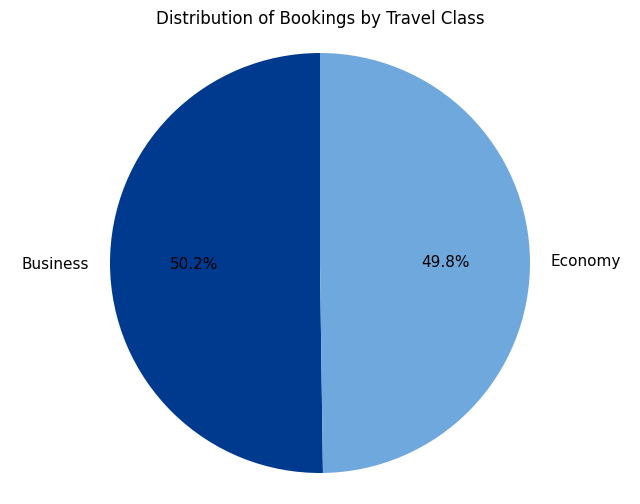

In [18]:
counts = df["class"].value_counts()
fig, ax = plt.subplots(figsize=(8, 6))
colors_vals = ["#003A8F", "#6FA8DC"][:len(counts)]
ax.pie(
    counts.values,
    labels=counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors_vals,
    textprops={"fontsize": 11}
)
ax.set_title("Distribution of Bookings by Travel Class")
ax.axis("equal")
plt.show()

Bar Chart: Top 10 Destinations by Total Revenue
The code displays a bar chart illustrating the top 10 highest-grossing destinations by total revenue.
The chart allows for clear identification of the destinations with the highest revenues,
providing insights into the financial performance of each destination.

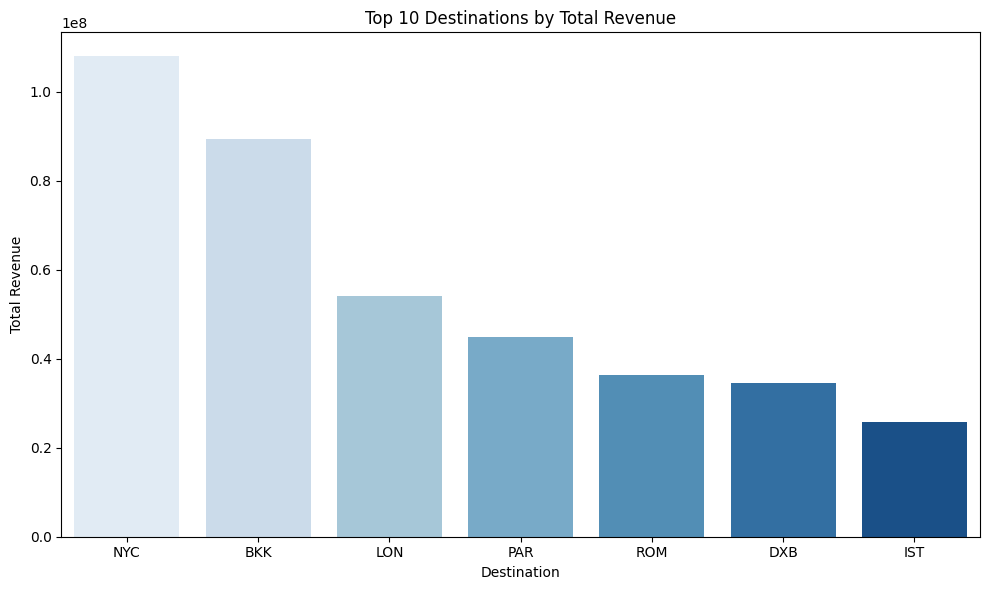

In [19]:
rev_by_dest = (
    df.groupby("destination", as_index=False)["revenue"]
      .sum()
      .sort_values("revenue", ascending=False)
      .head(10)
)
fig, ax = plt.subplots(figsize=(10, 6))
colors = sns.light_palette("blue", n_colors=len(rev_by_dest))
sns.barplot(data=rev_by_dest, x="destination", y="revenue",hue="destination", palette="Blues",legend=False, ax=ax)

ax.set_title("Top 10 Destinations by Total Revenue")
ax.set_xlabel("Destination")
ax.set_ylabel("Total Revenue")
plt.tight_layout()
plt.show()

Barh Chart: Average Refund by Cancellation Reason
The code displays a horizontal bar chart (Barh Chart) that illustrates the average refunds by cancellation reason.
The chart highlights which cancellation reasons lead to higher average refunds, providing insights into the factors affecting refunds.

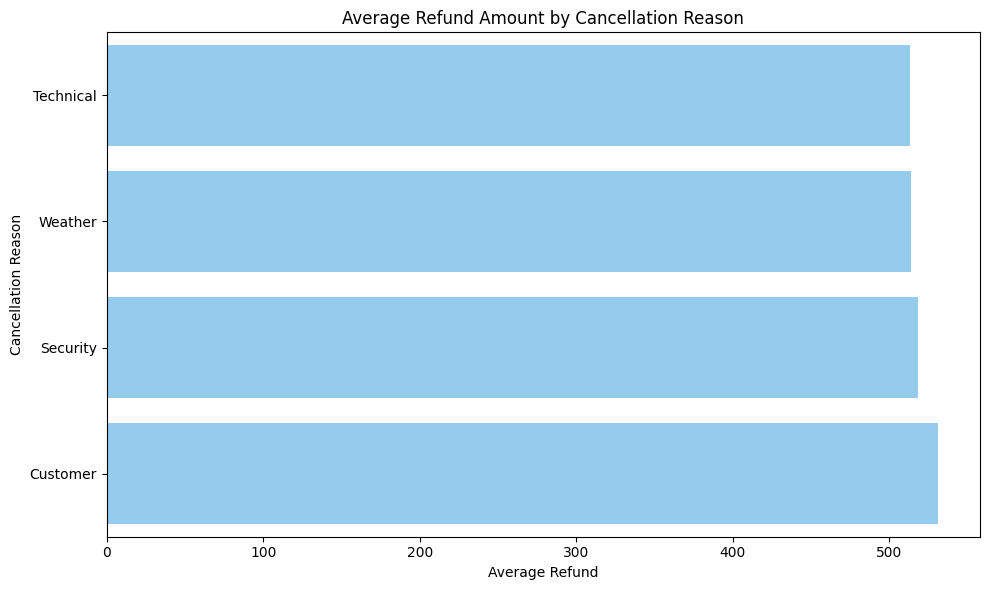

In [20]:
refund_by_reason = (
    df.groupby("reason", as_index=False)["refund"].mean()
      .sort_values("refund", ascending=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=refund_by_reason, y="reason", x="refund", color="#87CEFA", ax=ax)

ax.set_title("Average Refund Amount by Cancellation Reason")
ax.set_xlabel("Average Refund")
ax.set_ylabel("Cancellation Reason")
plt.tight_layout()
plt.show()

Ticket Price Histogram + KDE shows how prices are distributed.
Typically displays a right-skewed distribution: most tickets are cheap, few tickets are expensive.
This means there are many affordable options and few premium expensive options.  


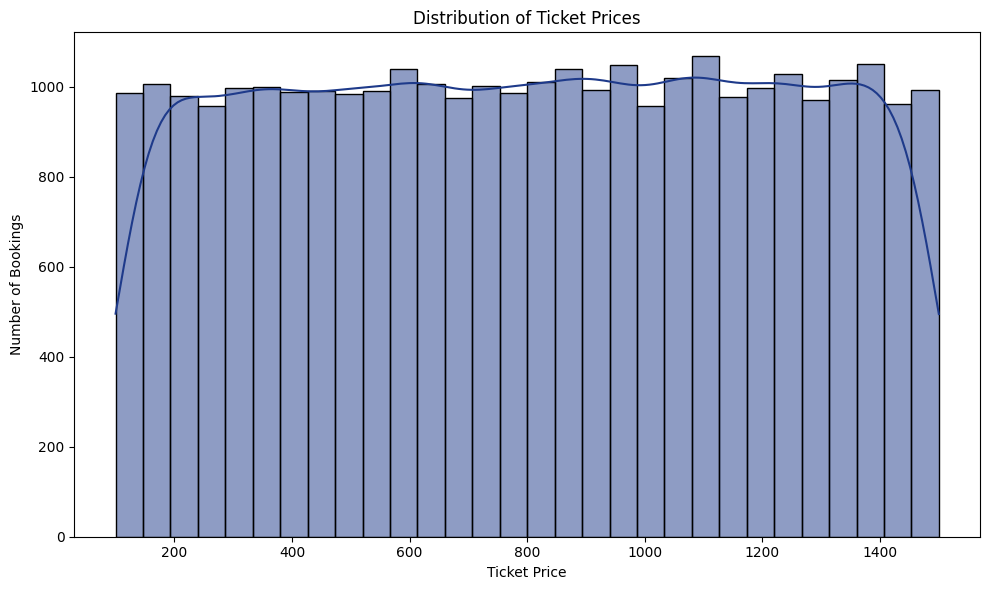

In [21]:
fig, ax = plt.subplots(figsize=(10, 6))
sns.histplot(df["price"].dropna(), bins=30, kde=True, color="#1E3A8A", ax=ax)

ax.set_title("Distribution of Ticket Prices")
ax.set_xlabel("Ticket Price")
ax.set_ylabel("Number of Bookings")
plt.tight_layout()
plt.show()

Histogram – Passenger Age Distribution
This chart displays the age range of passengers. -The code shows a histogram of passenger age distribution, which means:
• How many passengers are in each age group • Identifying the airline's main target audience • 
Understanding whether most customers are young, elderly, or middle-aged

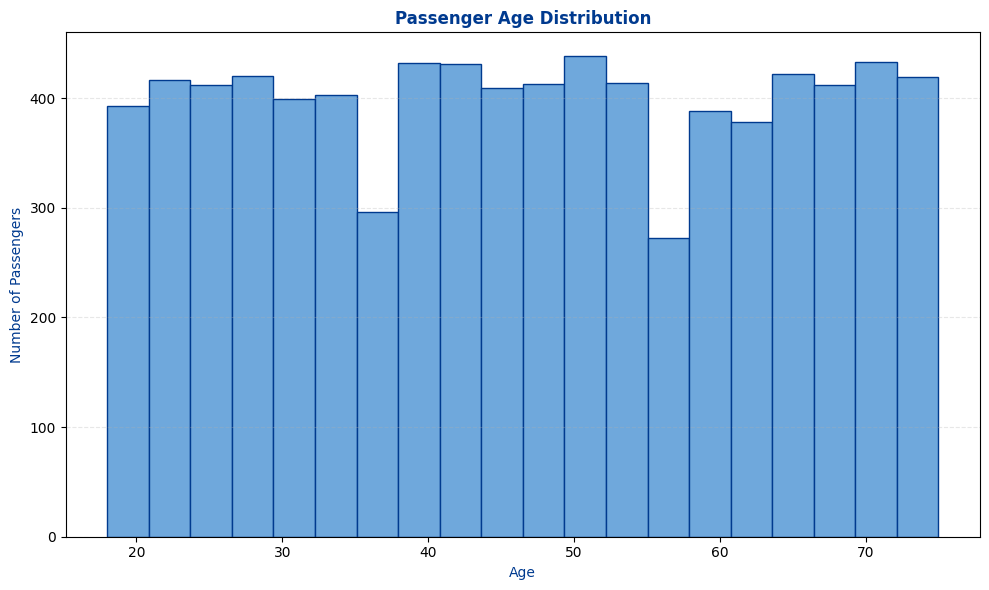

In [22]:
elal_blue = "#003A8F"
elal_light_blue = "#6FA8DC"
plt.figure(figsize=(10, 6))
plt.hist(
    df['age'].dropna(),
    bins=20,
    color=elal_light_blue,
    edgecolor=elal_blue)
plt.title("Passenger Age Distribution", color=elal_blue, fontweight='bold')
plt.xlabel("Age", color=elal_blue)
plt.ylabel("Number of Passengers", color=elal_blue)
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


Key findings (per chart)

Bookings by class (pie):

    -Focus: Two main categories; one is dominant (higher share of bookings).
    -Implication: Most passengers belong to the dominant class.
    
Revenue by destination — Top 10:

    -Focus: Top 10 destinations drive most revenue; revenue distribution is uneven.
    -Implication: A few destinations carry outsized revenue weight.
    
Average refund by cancellation reason:

    -Focus: Significant variation in average refunds by reason; some reasons incur higher refunds.
    -Implication: Refund costs depend on reason; some reasons are more costly.
    
Ticket price distribution (histogram + KDE):

    -Focus: Prices concentrate in a specific range; possible tails for high-priced tickets.
    -Implication: Main price bands exist with fewer bookings at price extremes.
        
Passenger age distribution:

    -Focus: Ages cluster in particular ranges; distribution is not uniform.
    -Implication: Specific age groups are the primary customer base.
    
##Data-driven conclusions

-Revenue and profitability concentrate on a small set of destinations and passenger classes — creating exposure if demand shifts.
-Refund costs are driven by particular cancellation reasons; addressing those can reduce costs.
-Core price bands suggest opportunities for tiered pricing and upsell.
-Age profile enables targeted marketing and tailored services.
    
##Business / research insights

-Marketing focus: Invest in promotion for high-revenue destinations and dominant passenger segments.
-Dynamic pricing: Optimize pricing to capture value at price tails (upsell opportunities).
-Operational risk management: Diversify routes or strengthen retention incentives for key destinations to reduce concentration risk.
-Refund analysis: Implement reason-based refund policies and analyze links between refund size and ticket/profile.
-Age segmentation: Tailor products/offers (family, business, youth) to dominant age segments.
    
##Actionable recommendations and future research directions

-Run A/B tests for campaigns targeting top destinations and age segments to measure ROI.
-Build a dynamic pricing roadmap: model historical price distribution to guide price adjustments.
-Perform micro-level cancellation analysis: correlate reason with ticket type, price, destination, and age to design tailored refund policies.
-Test demand sensitivity: assess the impact of external events, such as war and ceasefire, on the highest-revenue destinations.
-Product development: introduce upsell bundles or tailored insurance for costly cancellation reasons and price-sensitive segments.
-Continuous monitoring: implement a monthly dashboard for revenue by destination, cancellation rates by reason, 
    and price offers by age segment to detect trends early.
